In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("wordsforthewise/lending-club")

print("Path to dataset files:", path)

100%|██████████| 1.26G/1.26G [02:00<00:00, 11.3MB/s]

Extracting files...


Path to dataset files: C:\Users\user\.cache\kagglehub\datasets\wordsforthewise\lending-club\versions\3


In [3]:
print(os.listdir(path))

['accepted_2007_to_2018q4.csv', 'accepted_2007_to_2018Q4.csv.gz', 'rejected_2007_to_2018q4.csv', 'rejected_2007_to_2018Q4.csv.gz']


In [4]:
file_path = os.path.join(path, 'accepted_2007_to_2018q4.csv')

print(os.path.isfile(file_path))
print(os.path.isdir(file_path))

False
True


In [5]:
import os

folder = os.path.join(path, 'accepted_2007_to_2018q4.csv')

print(os.listdir(folder))

['accepted_2007_to_2018Q4.csv']


In [6]:
real_file = os.path.join(folder, os.listdir(folder)[0])

df = pd.read_csv(real_file, low_memory=False)
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df.tail()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
2260696,88985880,NaN,40000.0,40000.0,40000.0,60 months,10.49,859.56,B,B3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260697,88224441,NaN,24000.0,24000.0,24000.0,60 months,14.49,564.56,C,C4,...,NaN,NaN,Cash,Y,Mar-2019,ACTIVE,Mar-2019,10000.0,44.82,1.0
2260698,88215728,NaN,14000.0,14000.0,14000.0,60 months,14.49,329.33,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260699,Total amount funded in policy code 1: 1465324575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2260700,Total amount funded in policy code 2: 521953170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.isnull().sum()

id                             0
member_id                2260701
loan_amnt                     33
funded_amnt                   33
funded_amnt_inv               33
                          ...   
settlement_status        2226455
settlement_date          2226455
settlement_amount        2226455
settlement_percentage    2226455
settlement_term          2226455
Length: 151, dtype: int64

In [9]:
USE_COLS = [
    'loan_status',
    'emp_title',
    'addr_state',
    'issue_d',
    'loan_amnt',
    'term',
    'int_rate',
    'installment',
    'grade',
    'annual_inc',
    'dti',
    'delinq_2yrs',
    'fico_range_low',
    'open_acc',
    'revol_util',
    'pub_rec',
    'purpose',
    'home_ownership'
]

loan_df = df[USE_COLS].copy()

loan_df.shape

(2260701, 18)

In [10]:
default_status = [
    'Charged Off',
    'Default'
]

loan_df['loan_default'] = (
    loan_df['loan_status']
    .isin(default_status)
    .astype(int)
)

loan_df['loan_default'].value_counts()

loan_default
0    1992102
1     268599
Name: count, dtype: int64

In [11]:
loan_df.drop(
    columns=['loan_status'],
    inplace=True
)

In [12]:
loan_df.isnull().sum().sort_values(ascending=False)

emp_title         167002
revol_util          1835
dti                 1744
pub_rec               62
delinq_2yrs           62
open_acc              62
annual_inc            37
addr_state            33
issue_d               33
loan_amnt             33
installment           33
grade                 33
term                  33
int_rate              33
fico_range_low        33
purpose               33
home_ownership        33
loan_default           0
dtype: int64

In [13]:
loan_df.drop(
    columns=['emp_title'],
    inplace=True
)

In [14]:
num_cols = loan_df.select_dtypes(
    include=['int64','float64']
).columns

for col in num_cols:
    loan_df[col] = loan_df[col].fillna(
        loan_df[col].median()
    )

In [15]:
cat_cols = loan_df.select_dtypes(
    include='object'
).columns

for col in cat_cols:
    loan_df[col] = loan_df[col].fillna(
        loan_df[col].mode()[0]
    )

C:\Users\user\AppData\Local\Temp\ipykernel_8036\2335936553.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = loan_df.select_dtypes(


In [16]:
states = loan_df['addr_state'].unique()

np.random.seed(42)

state_geo = pd.DataFrame({
    'addr_state': states,
    'lat': np.random.uniform(25,49,len(states)),
    'lon': np.random.uniform(-124,-67,len(states))
})

state_geo.head()

,addr_state,lat,lon
0,PA,33.988963,-79.817429
1,SD,47.817143,-70.448560
2,IL,42.567855,-72.994841
3,NJ,39.367804,-89.919701
4,GA,28.744447,-71.453169


In [17]:
loan_df = loan_df.merge(
    state_geo,
    on='addr_state',
    how='left'
)

loan_df.head()

,addr_state,issue_d,loan_amnt,term,int_rate,installment,grade,annual_inc,dti,delinq_2yrs,fico_range_low,open_acc,revol_util,pub_rec,purpose,home_ownership,loan_default,lat,lon
0,PA,Dec-2015,3600.0,36 months,13.99,123.03,C,55000.0,5.91,0.0,675.0,7.0,29.7,0.0,debt_consolidation,MORTGAGE,0,33.988963,-79.817429
1,SD,Dec-2015,24700.0,36 months,11.99,820.28,C,65000.0,16.06,1.0,715.0,22.0,19.2,0.0,small_business,MORTGAGE,0,47.817143,-70.448560
2,IL,Dec-2015,20000.0,60 months,10.78,432.66,B,63000.0,10.78,0.0,695.0,6.0,56.2,0.0,home_improvement,MORTGAGE,0,42.567855,-72.994841
3,NJ,Dec-2015,35000.0,60 months,14.85,829.90,C,110000.0,17.06,0.0,785.0,13.0,11.6,0.0,debt_consolidation,MORTGAGE,0,39.367804,-89.919701
4,PA,Dec-2015,10400.0,60 months,22.45,289.91,F,104433.0,25.37,1.0,695.0,12.0,64.5,0.0,major_purchase,MORTGAGE,0,33.988963,-79.817429


In [18]:
np.random.seed(42)

loan_df['rainfall_mm'] = np.random.normal(
    100,
    30,
    len(loan_df)
)

loan_df['rainfall_deviation'] = np.random.normal(
    0,
    15,
    len(loan_df)
)

loan_df['temp_avg'] = np.random.normal(
    20,
    5,
    len(loan_df)
)

In [19]:
loan_df['ndvi_mean'] = np.random.uniform(
    0.2,
    0.9,
    len(loan_df)
)

loan_df['drought_flag'] = (
    loan_df['ndvi_mean'] < 0.35
).astype(int)

In [20]:
loan_df['soil_ph'] = np.random.uniform(
    5,
    8,
    len(loan_df)
)

loan_df['soil_organic_carbon'] = np.random.uniform(
    1,
    10,
    len(loan_df)
)

loan_df['soil_clay_pct'] = np.random.uniform(
    10,
    60,
    len(loan_df)
)

In [21]:
loan_df['soil_quality_score'] = (
    loan_df['soil_organic_carbon']*0.5 +
    loan_df['soil_ph']*0.3 +
    loan_df['soil_clay_pct']*0.2
)

In [22]:
loan_df.columns.tolist()

['addr_state',
 'issue_d',
 'loan_amnt',
 'term',
 'int_rate',
 'installment',
 'grade',
 'annual_inc',
 'dti',
 'delinq_2yrs',
 'fico_range_low',
 'open_acc',
 'revol_util',
 'pub_rec',
 'purpose',
 'home_ownership',
 'loan_default',
 'lat',
 'lon',
 'rainfall_mm',
 'rainfall_deviation',
 'temp_avg',
 'ndvi_mean',
 'drought_flag',
 'soil_ph',
 'soil_organic_carbon',
 'soil_clay_pct',
 'soil_quality_score']

In [23]:
loan_df['issue_d'] = pd.to_datetime(
    loan_df['issue_d'],
    format='%b-%Y',
    errors='coerce'
)

loan_df['issue_year'] = loan_df['issue_d'].dt.year
loan_df['issue_month'] = loan_df['issue_d'].dt.month

loan_df.drop(columns=['issue_d'], inplace=True)

In [24]:
categorical_cols = [
    'addr_state',
    'term',
    'grade',
    'purpose',
    'home_ownership'
]

loan_df = pd.get_dummies(
    loan_df,
    columns=categorical_cols,
    drop_first=True
)

In [25]:
loan_df.isnull().sum().sum()

np.int64(0)

In [26]:
loan_df = loan_df.fillna(loan_df.median(numeric_only=True))

In [27]:
X = loan_df.drop(
    columns=['loan_default']
)

y = loan_df['loan_default']

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [30]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [31]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score
)

print("Accuracy:",
      accuracy_score(y_test,y_pred))

print("\nROC-AUC:",
      roc_auc_score(y_test,y_prob))

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.8814153107105969

ROC-AUC: 0.7686675367833211
              precision    recall  f1-score   support

           0       0.88      1.00      0.94    398421
           1       0.59      0.01      0.01     53720

    accuracy                           0.88    452141
   macro avg       0.73      0.50      0.47    452141
weighted avg       0.85      0.88      0.83    452141



In [32]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

importance.head(15)

,Feature,Importance
21,issue_year,0.184310
74,grade_B,0.109785
1,int_rate,0.098443
75,grade_C,0.091442
76,grade_D,0.084614
73,term_ 60 months,0.029479
77,grade_E,0.028822
97,home_ownership_RENT,0.019595
22,issue_month,0.017741
78,grade_F,0.017573


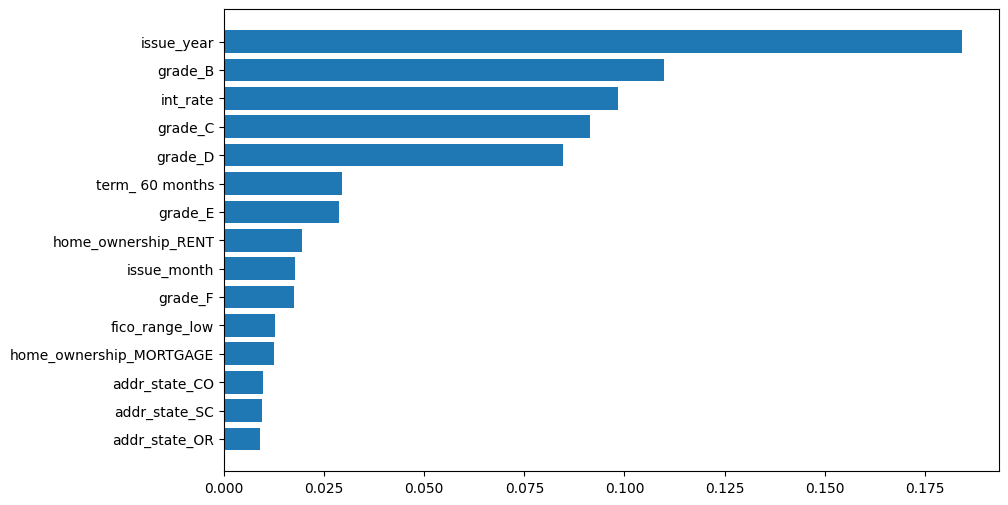

In [33]:
import matplotlib.pyplot as plt

top15 = importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top15['Feature'],
    top15['Importance']
)

plt.gca().invert_yaxis()

plt.show()

In [34]:
import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

C:\Users\user\AppData\Local\Temp\ipykernel_8036\219860562.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


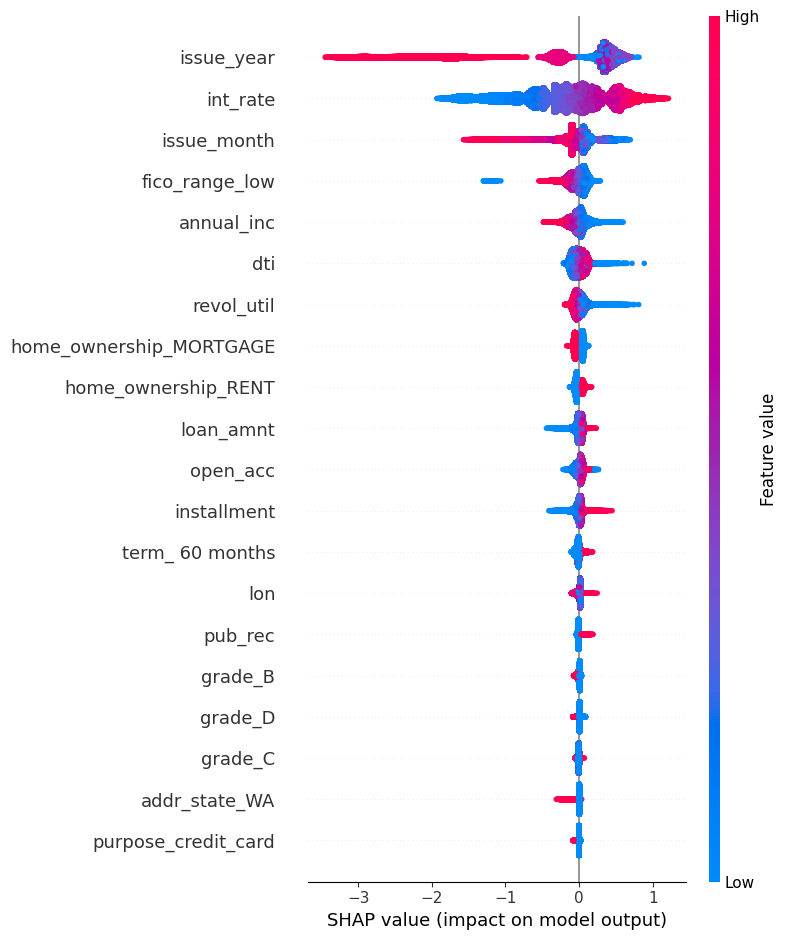

In [35]:
shap.summary_plot(
    shap_values,
    X_test
)

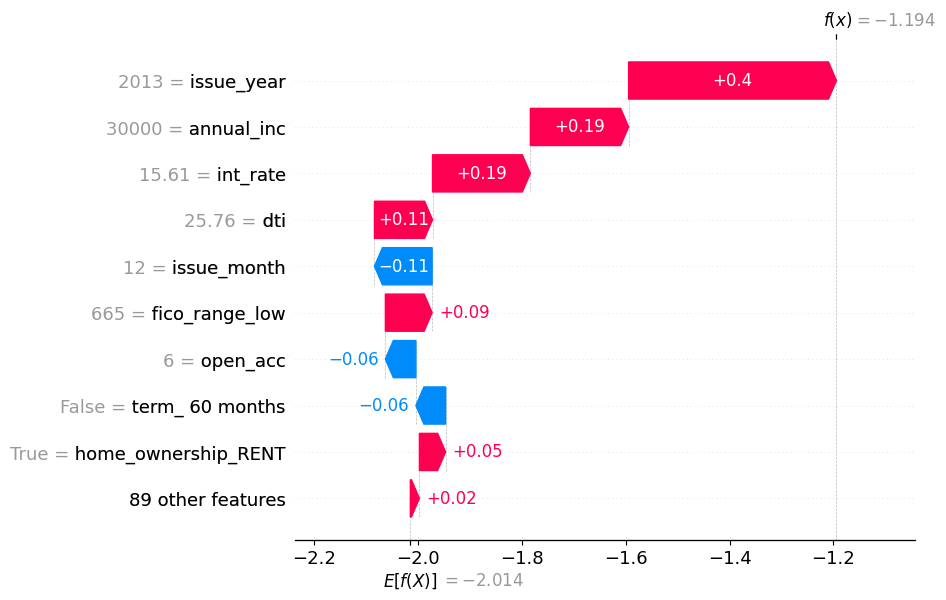

In [36]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)